# HDB Resale Price Analysis

This notebook visualizes HDB resale prices (Price Per Square Foot vs Remaining Lease).
You can customize the filters below to explore different towns, flat types, and models.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import sys

# Database File Path
DB_FILE = "transactions.db"

def get_data_optimized(db_file, towns=None, flat_types=None, models_exclude=None, months_ago=60):
    conn = sqlite3.connect(db_file)
    
    query = """
        SELECT 
            t.remaining_lease,
            (t.resale_price / (t.floor_area_sqm * 10.7639)) AS price_per_sqft
        FROM transactions t
        JOIN towns tw ON t.town_id = tw.id
        JOIN flat_types ft ON t.flat_type_id = ft.id
        JOIN flat_models fm ON t.flat_model_id = fm.id
        WHERE 1=1
    """
    params = []

    if towns:
        placeholders = ', '.join(['?'] * len(towns))
        query += f" AND tw.name IN ({placeholders})"
        params.extend(towns)

    if flat_types:
        placeholders = ', '.join(['?'] * len(flat_types))
        query += f" AND ft.name IN ({placeholders})"
        params.extend(flat_types)

    if models_exclude:
        placeholders = ', '.join(['?'] * len(models_exclude))
        query += f" AND fm.name NOT IN ({placeholders})"
        params.extend(models_exclude)

    if months_ago:
        query += " AND t.month >= date('now', ?)"
        params.append(f'-{months_ago} months')

    print("Executing query...")
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    return df

def get_plot_title(towns, flat_types, flat_models_exclude, months_ago):
    town_title = ', '.join(towns) if towns else 'ALL TOWNS'
    flat_type_title = ', '.join(flat_types) if flat_types else 'ALL FLATS'
    exclude_title = f"excluding {', '.join(flat_models_exclude)}" if flat_models_exclude else ''
    
    now = datetime.now()
    year, week_num, _ = now.isocalendar()

    return f"PSF vs Remaining Lease for {flat_type_title} in {town_title}\n{exclude_title} (Last {months_ago} months, Week {week_num} {year})"

def plot(df, title):
    plt.figure(figsize=(14, 8))
    df['remaining_lease_int'] = df['remaining_lease'].astype(int)
    
    if not df.empty:
        min_year = int(df['remaining_lease_int'].min())
        max_year = int(df['remaining_lease_int'].max())
        full_range = range(min_year, max_year + 1)
    else:
        full_range = None

    sb = sns.boxplot(x='remaining_lease_int', y='price_per_sqft', data=df, order=full_range)
    sb.invert_xaxis()
    plt.title(title)
    plt.xlabel('Remaining Lease (Years)')
    plt.ylabel('Price Per Square Foot (SGD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Executing query...
Found 1267 records. Generating plot...


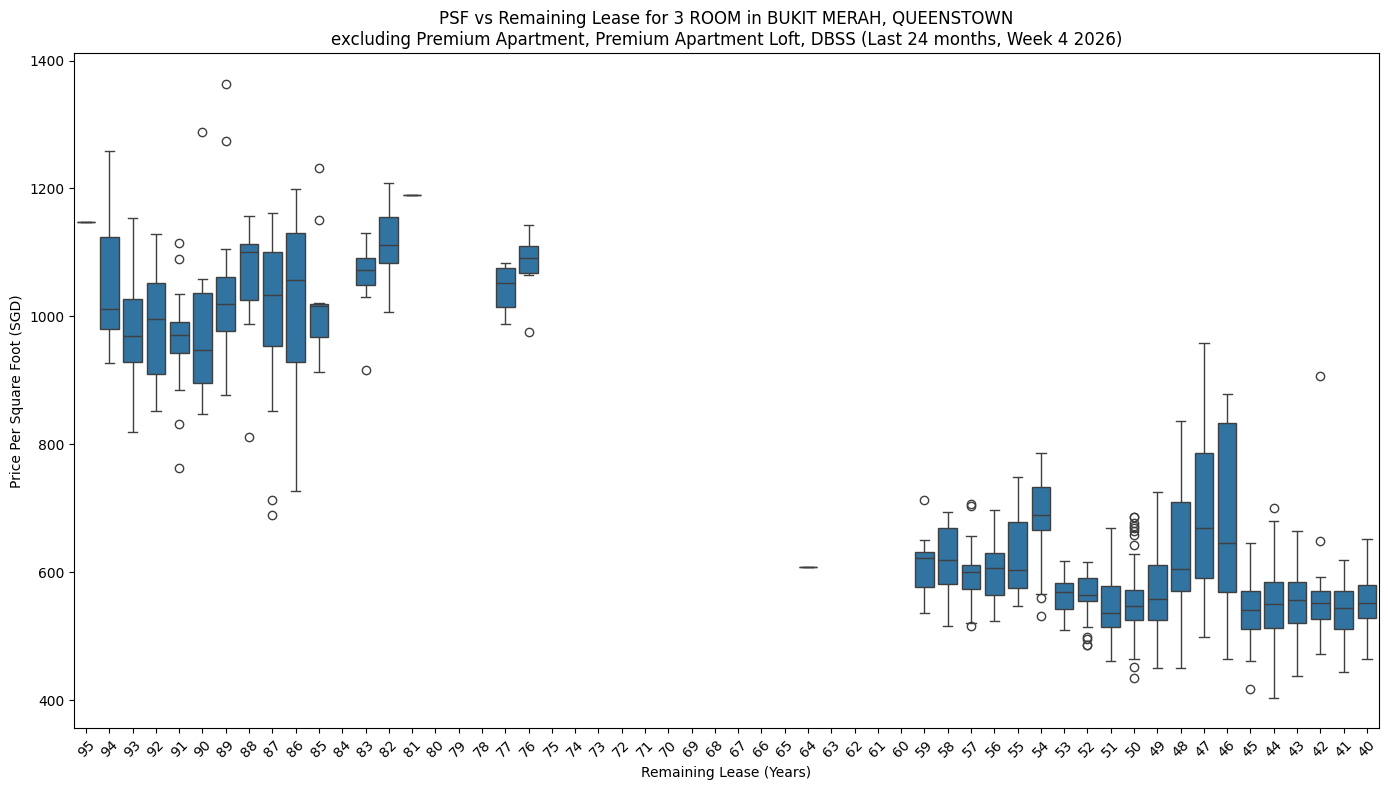

In [4]:
# === CONFIGURATION CELL ===

# LIST OF ALL AVAILABLE TOWNS:
# 'ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG',
# 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG',
# 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS',
# 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES',
# 'TOA PAYOH', 'WOODLANDS', 'YISHUN'

towns = ['BUKIT MERAH', 'QUEENSTOWN']  # Leave empty [] for ALL towns

# LIST OF ALL AVAILABLE FLAT TYPES:
# '1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION'

flat_types = ['3 ROOM']  # Leave empty [] for ALL flat types

# LIST OF ALL AVAILABLE FLAT MODELS:
# 'Improved', 'New Generation', 'Model A', 'Standard', 'Apartment', 'Simplified',
# 'Model A-Maisonette', 'Maisonette', 'Multi Generation', 'Adjoined flat',
# 'Premium Apartment', 'Terrace', 'Improved-Maisonette', 'Premium Maisonette',
# '2-room', 'Model A2', 'DBSS', 'Type S1', 'Type S2', 'Premium Apartment Loft', '3Gen'

flat_models_exclude = ['Premium Apartment', 'Premium Apartment Loft', 'DBSS'] 

# Time range filter
months_ago = 24


# === EXECUTION CELL ===

df = get_data_optimized(DB_FILE, towns, flat_types, flat_models_exclude, months_ago)

if df.empty:
    print("No data found for the selected filters.")
else:
    print(f"Found {len(df)} records. Generating plot...")
    title = get_plot_title(towns, flat_types, flat_models_exclude, months_ago)
    plot(df, title)
    